In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sig
from scipy.stats import ttest_ind
import mne
import random as rand

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
#This function takes in a gdf file path and converts it to a pandas dataframe
def path_to_dataframe(FILE_PATH, fs):
    eog = ['EOG-left', 'EOG-central', 'EOG-right']

    #read raw data from gdf using mne
    file_raw = mne.io.read_raw_gdf(FILE_PATH, eog=eog)

    #read events from the gdf annotation
    events, event_id = mne.events_from_annotations(file_raw)
    

    #convert raw to dataframe
    eeg_data = file_raw.to_data_frame()
    eeg_data = eeg_data.drop(eeg_data.columns[0], axis=1)
    eeg_data = eeg_data.drop(eeg_data.columns[-1], axis=1)
    eeg_data = eeg_data.drop(eeg_data.columns[-1], axis=1)
    eeg_data = eeg_data.drop(eeg_data.columns[-1], axis=1)
    eeg_data['event'] = 0


    #convert events to dataframe
    events_df = pd.DataFrame(events)
    events_df = events_df.drop(events_df.columns[1], axis=1)

    #iterates through events and creates a time-matched list to correspond events with eeg timestamps
    track = 0
    hold_size = len(eeg_data)
    hold_list = [0] * hold_size
    for i in events_df[0]:
        time_check = i
        hold_list[i] = events_df.at[track, 2]
        track = track + 1

    #iterates through hold_list (which has markers for the start of trials/ events) and populates a list with labels to associate with eeg timestamps
    one_count = 0
    two_count = 0
    three_count = 0
    four_count = 0
    five_count = 0
    six_count = 0
    seven_count = 0
    eight_count = 0
    nine_count = 0
    ten_count = 0
    hold_two = hold_list.copy()
    for i in range(len(hold_list)):
    #Correspondence of numbers dictionary
    #1023: 1, Rejected trial
    #1072: 2, Eye movements
    #276: 3, Idling EEG (eyes open)
    #277: 4, Idling EEG (eyes closed)
    #32766: 5, Start of a new run
    #768: 6, Start of a trial
    #769: 7, Cue onset left (class 1)
    #770: 8, Cue onset right (class 2)
    #771: 9, Cue onset foot (class 3)
    #772: 10, Cue onset tongue (class 4)
    
        if hold_list[i] == 1:
            #1 indicates a rejected trial (See above "dictionary")
            #Trials are roughly 6 seconds
            #for 250 Hz, this means a trial is approximately 1500 samples in duration

            #Upon seeing a '1', or rejected trial, set the next 6 seconds to '0'
            hold_two[i:(i+(fs*6))] = [0] * (fs*6)
            #Counters to numerate the appearance of each class, primarily for debugging purposes
            one_count = one_count + 1
        elif hold_list[i] == 2:
            #2-4 are irrelevant, also set to '0'
            hold_two[i] = 0
            two_count = two_count + 1
        elif hold_list[i] == 3:
            hold_two[i] = 0
            three_count = three_count + 1
        elif hold_list[i] == 4:
            hold_two[i] = 0
            four_count = four_count + 1
        elif hold_list[i] == 5:
            #5 indicates a new run, starting after a rest period
            #Also irrelevant to classification, so set to '0'
            hold_two[i] = 0
            five_count = five_count + 1
    
        elif hold_list[i] == 6:
            #6 indicates the start of the 6 second trial window
            #Motor Imagery should begin 2 seconds after every 6 second window begins (500 samples)
            #Since each MI task is accurately recorded, this also can be set to '0'
            hold_two[i] = 0
            six_count = six_count + 1
        elif hold_list[i] == 7:
            #7 Indicates left hand MI, or 'class 1'
            #Each motor Imagery task should last ~4 seconds, though the 'end' is not indicated within the data
            #Seeing a 7 will, similarly to rejected trial above, set the next 4 seconds to a value of '1'
            hold_two[i:(i+(fs*4))] = [1] * (fs*4)
            seven_count = seven_count + 1
        if hold_list[i] == 8:
            #8 indicates right hand MI, 'class 2'
            #Set next 4 seconds to '2'
            hold_two[i:(i+(fs*4))] = [2] * (fs*4)
            eight_count = eight_count + 1
        if hold_list[i] == 9:
            #9 - Foot MI
            #Set to '3'
            hold_two[i:(i+(fs*4))] = [3] * (fs*4)
            nine_count = nine_count + 1
        if hold_list[i] == 10:
            #10 - Tongue MI
            #Set to '4'
            hold_two[i:(i+(fs*4))] = [4] * (fs*4)
            ten_count = ten_count + 1

    eeg_data['event'] = hold_two
    return eeg_data

print("Done")

Done


In [3]:
#Deprecated, used in a previous iteration

#This function takes in a dataframe, and converts it for use in the 'identifier' algorithm
#Assumes the nature of the dataframe from 'path_to_dataframe'
#def dataframe_to_nparr(df):
    #arr_1_temp = np.asarray(df).T
    #arr_1 = np.delete(arr_1_temp, 22, axis=0)
    #return arr_1

In [4]:
#This is a deprecated codeblock that I'm keeping in case I utilize it later

#freq = 250
#FILE_PATH_1 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A01T.gdf'
#FILE_PATH_2 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A02T.gdf'
#FILE_PATH_3 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A03T.gdf'
#FILE_PATH_4 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A04T.gdf'
#FILE_PATH_5 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A05T.gdf'

#subj1 = path_to_dataframe(FILE_PATH_1, freq)
#subj2 = path_to_dataframe(FILE_PATH_2, freq)
#subj3 = path_to_dataframe(FILE_PATH_3, freq)
#subj4 = path_to_dataframe(FILE_PATH_4, freq)
#subj5 = path_to_dataframe(FILE_PATH_5, freq)



In [5]:
#Below is the Identification ML algorithm, which will take in a 22x1000 'sample'
#The convolutional layers efficiently learn spatial relationships and, as discussed in class,
#Are uniquely adequate for EEG classification

class IDTest(nn.Module):
    def __init__(self, n_channels=22, time_steps=1000):
        super().__init__()
        self.features = nn.Sequential(
            
            nn.Conv1d(in_channels=22, out_channels=32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),
            
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)
print("Done")

Done


In [6]:
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print("Done")

PyTorch version: 2.11.0+cpu
Using device: cpu
Done


In [7]:
#I have found and adapted code that can take in "n_sample", "n_channel", "n_timestep" data
#Each sample is a 2D data-snippet of an n_timestep recording of n_channels

#If I can, using what I have already devised, create (sample, channel, timestamp) tensors
#I can feed these tensors through the convolutional network
#And identify which of two individuals these come from

In [8]:
#The below method will be given the above devised pandas dataframe from 'path_to_dataframe'
#It will find 20 total samples
#4 each from '0' (Idle), '1', '2', '3', '4' (events, as described above)
#it will return a tensor corresponding to an individual
#This tensor will be used for training of the model, below is provided a method to grab a random test set

def prep_for_ID(df, f, test_ind):
    
    numtimestamp = f * 4
    hold = np.ndarray((20,22,numtimestamp))
    ind = test_ind
    for i in range(4):
        val = df.at[ind, 'event']
        while(val != 0):
            ind = ind + 1
            val = df.at[ind, 'event']
        even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
        hold[i] = even.T
        ind = ind + numtimestamp
    ind = test_ind
    for i in range(4):
        val = df.at[ind, 'event']
        while(val != 1):
            ind = ind + 1
            val = df.at[ind, 'event']
        even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
        hold[i+4] = even.T
        ind = ind + numtimestamp
    ind = test_ind
    for i in range(4):
        val = df.at[ind, 'event']
        while(val != 2):
            ind = ind + 1
            val = df.at[ind, 'event']
        even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
        hold[i+8] = even.T
        ind = ind + numtimestamp
    ind = test_ind
    for i in range(4):
        val = df.at[ind, 'event']
        while(val != 3):
            ind = ind + 1
            val = df.at[ind, 'event']
        even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
        hold[i+12] = even.T
        ind = ind + numtimestamp
    ind = test_ind
    for i in range(4):
        val = df.at[ind, 'event']
        while(val != 4):
            ind = ind + 1
            val = df.at[ind, 'event']
        even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
        hold[i+16] = even.T
        ind = ind + numtimestamp
    #tens = torch.from_numpy(hold)
    tens = torch.FloatTensor(hold)
    return tens

#This method grabs a single sample at the specified index (as a tensor)
#for testing of model
def test_tens_ID(df, f, test_ind):
    numtimestamp = f * 4
    hold = np.ndarray((1,22,numtimestamp))
    ind = test_ind
    even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
    hold[0] = even.T
    tens = torch.FloatTensor(hold)
    return tens

def test_tens_ID_2(df, f):
    numtimestamp = f * 4
    hold = np.ndarray((1,22,numtimestamp))
    ind = rand.randint(10000, 600000)
    #print("Randint:", ind)
    even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
    hold[0] = even.T
    tens = torch.FloatTensor(hold)
    return tens
print("Done")

Done


In [9]:
#The below initializes gdfs as the required tensor format
#FILE_PATH_1 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A01T.gdf'
#FILE_PATH_2 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A03T.gdf'
#freq = 250
#n_samples = 20
#n_channels = 22
#time_steps = freq*4
#subj1 = path_to_dataframe(FILE_PATH_1, freq)
#subj2 = path_to_dataframe(FILE_PATH_2, freq)

#ind = 100000
#tensor_x_1 = prep_for_ID(subj1, freq, ind)
#tensor_x_2 = prep_for_ID(subj2, freq, ind )

#x = torch.cat([tensor_x_1, tensor_x_2], dim=0)
#y = torch.cat([torch.zeros(n_samples, 1), torch.ones(n_samples, 1)], dim=0)
print("Done")

Done


In [10]:
#below is test space for the "prep_for_ID" function
#Commented out since IDTest_n renders it obsolete
#model = IDTest(n_channels, time_steps)
#optimizer = optim.Adam(model.parameters(), lr=0.001)
#criterion = nn.BCELoss()

#epoch = 100
#for i in range(epoch):
    #optimizer.zero_grad()
    #preds = model(x)
    #loss = criterion(preds, y)
    #loss.backward()
    #optimizer.step()
    #if (i + 1) % 10 == 0:
        #print(f"Epoch {i+1}, Loss: {loss.item():.4f}")

#By assigning an arbitrary index of EEG dataframe to the test function, we grab a testable sample from the subjects signals

#signal = test_tens_ID(subj1, freq, 459332)
#model.eval()
#with torch.no_grad():
    #prob = model(signal).item()
    #print("Shown below is the model's predictions after training, with the listed correspondences:")
    #print("0 - subj1\n1 - subj2")
    #print("Test 1 (subj1):", prob)

#signal = test_tens_ID(subj2, freq, 250332)
#model.eval()
#with torch.no_grad():
    #prob = model(signal).item()
    #print("Test 2 (subj2):", prob)

In [11]:
#Below is an adaptation of the above 'IDTest' model
#This one is modified to be able to discriminate between a greater number of individuals
#Technically speaking, this model renders the previous one redundant, as n_subj could simply be set to 2
class IDTest_n(nn.Module):
    def __init__(self, n_channels=22, time_steps=1000, n_subj=4):
        super().__init__()
        self.features = nn.Sequential(
            
            nn.Conv1d(in_channels=22, out_channels=32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),
            
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_subj), #Outputs a (n, 1) tensor
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [12]:
#Initialize files as dataframes
FILE_PATH_1 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A01T.gdf'
FILE_PATH_2 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A03T.gdf'
FILE_PATH_3 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A05T.gdf'
FILE_PATH_4 = 'C:/Users/semee/Class/EEEE 536/Project/Data/A06T.gdf'
freq = 250
numsubj = 4
n_samples = 20
n_channels = 22
time_steps = freq*4
subj1 = path_to_dataframe(FILE_PATH_1, freq)
subj2 = path_to_dataframe(FILE_PATH_2, freq)
subj3 = path_to_dataframe(FILE_PATH_3, freq)
subj4 = path_to_dataframe(FILE_PATH_4, freq)
print("Done")

Extracting GDF parameters from C:/Users/semee/Class/EEEE 536/Project/Data/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Extracting GDF parameters from C:/Users/semee/Class/EEEE 536/Project/Data/A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Extracting GDF parameters from C:/Users/semee/Class/EEEE 536/Project/Data/A05T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Extracting GDF parameters from C:/Users/semee/Class/EEEE 536/Project/Data/A06T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Done


In [92]:
#Convert dataframes to single tensor
ind = 100000
tensor_x_1 = prep_for_ID(subj1, freq, ind)
tensor_x_2 = prep_for_ID(subj2, freq, ind)
tensor_x_3 = prep_for_ID(subj3, freq, ind)
tensor_x_4 = prep_for_ID(subj4, freq, ind)

x = torch.cat([tensor_x_1, tensor_x_2, tensor_x_3, tensor_x_4], dim=0)
hold = np.zeros((n_samples*numsubj, numsubj))
rownum = 0
for i in range(numsubj):
    hold[rownum:rownum+n_samples, i] = 1
    rownum = rownum + n_samples
y = torch.FloatTensor(hold)
print("Done")

Done


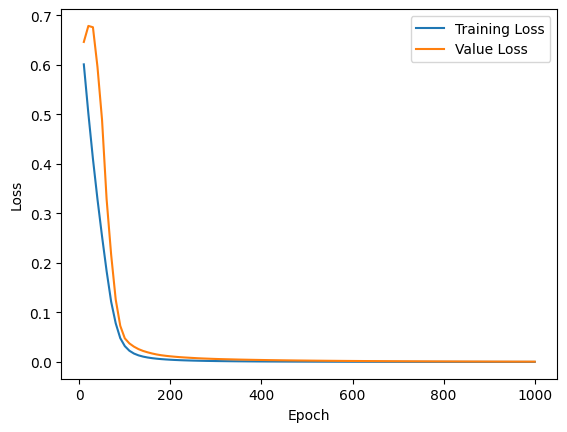

In [94]:
#Run n_subject identifier
model = IDTest_n(n_channels, time_steps, numsubj)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

subjects = [subj1, subj2, subj3, subj4]
signals = torch.FloatTensor([])
train = []
val = []
x_ax = []
y_test = torch.FloatTensor([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
epoch = 1000
for i in subjects:
    signals = torch.cat([signals, test_tens_ID_2(i, freq)], dim=0)
for i in range(epoch):
    model.train()
    optimizer.zero_grad()
    preds = model(x)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()
    if (i + 1) % 10 == 0:
        train.append(loss.item())
        model.eval()
        val_loss_hold = 0
        with torch.no_grad():
            prob = model(signals)
            val_loss = criterion(prob, y_test)
        val.append(val_loss)
        x_ax.append(i+1)
plt.plot(x_ax, train)
plt.plot(x_ax, val)
plt.xlabel("Epoch")
plt.ylabel("Loss")
labels = ["Training Loss", "Value Loss"]
plt.legend(labels)
plt.show()


#Testing;
#Uses above method to grab a random 4 second sample from anywhere in the data
#prints a tensor with four values associated with probability
#Highest column in tensor shows which subject the algorithm assumes

In [21]:
#These methods will be used to prep samples for the above model
#prep_for_gest will take in a dataframe and a gesture class (0,1,2...)
#and will return a tensor with five unique samples of that specified gesture
def prep_for_gest(df, f, c_num):
    
    numtimestamp = f * 4
    hold = np.ndarray((5,22,numtimestamp))
    ind = rand.randint(10000, 600000)
    for i in range(5):
        val = df.at[ind, 'event']
        val0 = df.at[ind+numtimestamp-1, 'event']
        while(val != c_num or val0 != c_num):
            if ind > 650000:
                ind = 3000
            ind = ind + 1
            val = df.at[ind, 'event']
            val0 = df.at[ind+numtimestamp-1, 'event']
        even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
        hold[i] = even.T
        ind = ind + numtimestamp
    tens = torch.FloatTensor(hold)
    return tens

def test_tens_gest(df, f, c_num):
    numtimestamp = f * 4
    hold = np.ndarray((1,22,numtimestamp))
    ind = rand.randint(10000, 600000)
    #print("Randint:", ind)
    val = df.at[ind, 'event']
    val0 = df.at[ind+numtimestamp-1, 'event']
    while(val != c_num or val0 != c_num):
        if ind > 650000:
            ind = 3000
        ind = ind + 1
        val = df.at[ind, 'event']
        val0 = df.at[ind+numtimestamp-1, 'event']
    #print(df.at[ind, 'event'])
    #print(df.at[ind+numtimestamp-1, 'event'])
    even = df.iloc[ind:(ind+numtimestamp),0:22].to_numpy()
    hold[0] = even.T
    tens = torch.FloatTensor(hold)
    return tens

In [86]:
#Below is test space for the sample prep methods
#tensor_x_1 = prep_for_ID(subj1, freq, ind)
#tensor_x_2 = prep_for_ID(subj2, freq, ind)
#tensor_x_3 = prep_for_ID(subj3, freq, ind)
#tensor_x_4 = prep_for_ID(subj4, freq, ind)

subjects = [subj1]
x_0 = torch.tensor([])
x_1 = torch.tensor([])
x_2 = torch.tensor([])
x_3 = torch.tensor([])
x_4 = torch.tensor([])
for i in subjects:
    tensor_subjx_0 = prep_for_gest(i, freq, 0)
    tensor_subjx_1 = prep_for_gest(i, freq, 1)
    tensor_subjx_2 = prep_for_gest(i, freq, 2)
    tensor_subjx_3 = prep_for_gest(i, freq, 3)
    tensor_subjx_4 = prep_for_gest(i, freq, 4)
    x_0 = torch.cat([x_0, tensor_subjx_0], dim=0)
    x_1 = torch.cat([x_1, tensor_subjx_1], dim=0)
    x_2 = torch.cat([x_2, tensor_subjx_2], dim=0)
    x_3 = torch.cat([x_3, tensor_subjx_3], dim=0)
    x_4 = torch.cat([x_4, tensor_subjx_4], dim=0)
x = torch.cat([x_0, x_1, x_2, x_3, x_4], dim=0)

rownum = 0
hold = np.zeros((((5)*5), 5))
for i in range(5):
    hold[rownum:rownum + 5, i] = 1
    rownum = rownum + 5
y = torch.FloatTensor(hold)
print(y.shape)
print(x.shape)
print("Done")

torch.Size([25, 5])
torch.Size([25, 22, 1000])
Done


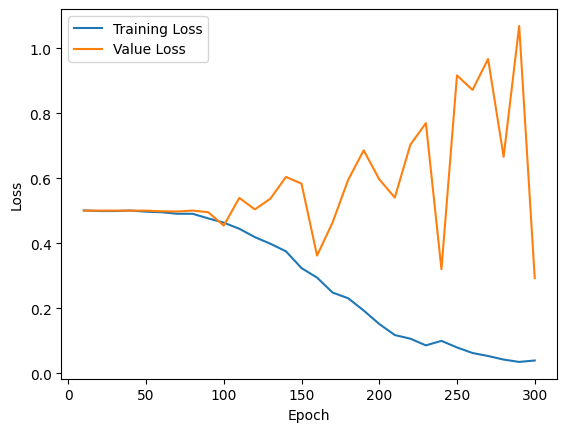

In [88]:
#Run gesture identifier
model = GestNet()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCELoss()


train = []
val = []
x_ax = []
y_test = torch.FloatTensor([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1, 0], [0, 0, 0, 0, 1]])
epoch = 300


for i in range(epoch):
    model.train()
    optimizer.zero_grad()
    preds = model(x)
    probabilities = torch.softmax(preds, dim=1) 
    loss = criterion(probabilities, y)
    loss.backward()
    optimizer.step()
    if (i + 1) % 10 == 0:
        train.append(loss.item())
        model.eval()
        val_loss_hold = 0
        signals = torch.tensor([])
        for s in range(5):
            signals = torch.cat([signals, test_tens_gest(subj1, freq, s)], dim=0)
        with torch.no_grad():  
            prob = model(signals)
            est = torch.softmax(prob, dim=1) 
            val_loss_hold = criterion(est, y_test)
        val_loss = val_loss_hold
        val.append(val_loss)
        x_ax.append(i+1)
        
plt.plot(x_ax, train)
plt.plot(x_ax, val)
plt.xlabel("Epoch")
plt.ylabel("Loss")
labels = ["Training Loss", "Value Loss"]
plt.legend(labels)
plt.show()

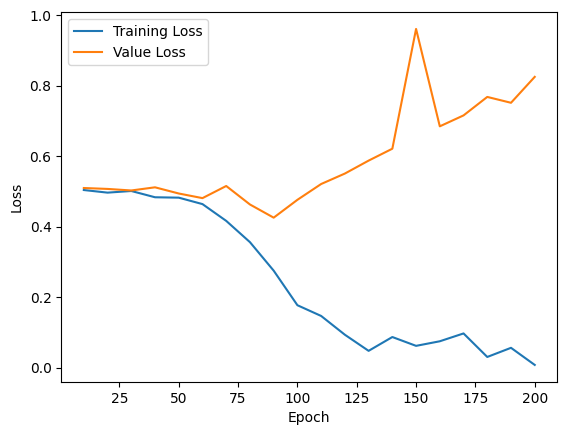

In [97]:
model = GestNet()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCELoss()


train = []
val = []
x_ax = []
y_test = torch.FloatTensor([[0, 1, 0, 0, 0], [0, 0, 1, 0, 0]])
epoch = 200
x_1 = test_tens_gest(subj1, freq, 1)
x_2 = test_tens_gest(subj1, freq, 2)
x = torch.cat([x_1, x_2], dim=0)
y = y_test

for i in range(epoch):
    model.train()
    optimizer.zero_grad()
    preds = model(x)
    probabilities = torch.softmax(preds, dim=1) 
    loss = criterion(probabilities, y)
    loss.backward()
    optimizer.step()
    if (i + 1) % 10 == 0:
        train.append(loss.item())
        model.eval()
        val_loss_hold = 0
        signals = torch.tensor([])
        val_loss = 0
        for s in range(2):
            signals = torch.cat([signals, test_tens_gest(subj2, freq, s+1)], dim=0)
        with torch.no_grad():  
            prob = model(signals)
            est = torch.softmax(prob, dim=1) 
            val_loss = val_loss + criterion(est, y_test)
        val.append(val_loss)
        x_ax.append(i+1)
        
plt.plot(x_ax, train)
plt.plot(x_ax, val)
plt.xlabel("Epoch")
plt.ylabel("Loss")
labels = ["Training Loss", "Value Loss"]
plt.legend(labels)
plt.show()

In [84]:
signal = test_tens_gest(subj1, freq, 1)
print(signal.shape)
model.eval()
with torch.no_grad():
    prob = model(signal)
    print("gest1:", prob)

torch.Size([1, 22, 1000])
gest1: tensor([[-0.7451,  3.1905, -0.8069, -1.7273, -1.3049]])


In [112]:
#The below algorithm will take in EEG samples identically to the previous algorithm
#The major difference is that this algorithm will be trained to identify from four gestures
#0,1,2,3,4 as aforementioned
#Which will be pooled across the subjects, so as to average out the individual differences
#It will eventually be able to take in a single sample, and return its gesuture classification
class GestNet(nn.Module):
    def __init__(self, n_channels=22, time_steps=1000, n_gest=5, lstm_hidden=128, lstm_layers=2, dropout=0.5):
        super().__init__()
        
        self.input_norm = nn.BatchNorm1d(n_channels)
        
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_channels, out_channels=32, kernel_size=25, padding=12),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.MaxPool1d(2),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden, 
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
            bidirectional=False,
        )

        self.lstm_norm = nn.LayerNorm(lstm_hidden)
        
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_gest),
        )

    def forward(self, x):
        x = self.input_norm(x)          # normalize EEG channels
        x = self.cnn(x)                 # (batch, 128, T//8)
        x = x.permute(0, 2, 1)         # (batch, T//8, 128) for LSTM
        lstm_out, _ = self.lstm(x)
        x = self.lstm_norm(lstm_out[:, -1, :])  # take last timestep + normalize
        return self.classifier(x)

In [177]:
def augment_eeg(x, noise_std=0.05, shift_max=10):
    # Gaussian noise
    x = x + torch.randn_like(x) * noise_std
    # Random time shift
    shift = torch.randint(-shift_max, shift_max, (1,)).item()
    x = torch.roll(x, shift, dims=-1)
    return x

In [180]:
x_0 = prep_for_gest(subj1, freq, 0)
x_1 = prep_for_gest(subj1, freq, 1)
x_2 = prep_for_gest(subj1, freq, 2)
x_3 = prep_for_gest(subj1, freq, 3)
x_4 = prep_for_gest(subj1, freq, 4)
x_hold = torch.cat([x_0, x_1, x_2, x_3, x_4], dim=0)
x = torch.FloatTensor([])
for i in range(10):
    x = torch.cat([x, x_hold], dim=0)

hold_0 = torch.tensor((np.zeros((5,))), dtype=torch.long)
hold_1 = torch.tensor((np.ones((5,))), dtype=torch.long)
hold_2 = torch.tensor((np.ones((5,)) * 2), dtype=torch.long)
hold_3 = torch.tensor((np.ones((5,)) * 3), dtype=torch.long)
hold_4 = torch.tensor((np.ones((5,)) * 4), dtype=torch.long)
y_hold = torch.cat([hold_0, hold_1, hold_2, hold_3, hold_4], dim=0)
y = torch.LongTensor([])
for i in range(10):
    y = torch.cat([y, y_hold], dim=0)

x_0 = prep_for_gest(subj2, freq, 0)
x_1 = prep_for_gest(subj2, freq, 1)
x_2 = prep_for_gest(subj2, freq, 2)
x_3 = prep_for_gest(subj2, freq, 3)
x_4 = prep_for_gest(subj2, freq, 4)
x_test = torch.cat([x_0, x_1, x_2, x_3, x_4], dim=0)

hold_0 = torch.tensor((np.zeros((5,))), dtype=torch.long)
hold_1 = torch.tensor((np.ones((5,))), dtype=torch.long)
hold_2 = torch.tensor((np.ones((5,)) * 2), dtype=torch.long)
hold_3 = torch.tensor((np.ones((5,)) * 3), dtype=torch.long)
hold_4 = torch.tensor((np.ones((5,)) * 4), dtype=torch.long)
y_test = torch.cat([hold_0, hold_1, hold_2, hold_3, hold_4], dim=0)

print(x.shape)
print(x_test.shape)
print(y.shape)
print(y_test.shape)
print("Done")

torch.Size([250, 22, 1000])
torch.Size([25, 22, 1000])
torch.Size([250])
torch.Size([25])
Done


Classes in train: [0, 1, 2, 3, 4]
Classes in test:  [0, 1, 2, 3, 4]
x mean/std: 0.394 / 10.751
Predicted class distribution:
  Class 0: 17 predictions
  Class 1: 4 predictions
  Class 2: 0 predictions
  Class 3: 3 predictions
  Class 4: 1 predictions

Actual class distribution:
  Class 0: 5 samples
  Class 1: 5 samples
  Class 2: 5 samples
  Class 3: 5 samples
  Class 4: 5 samples


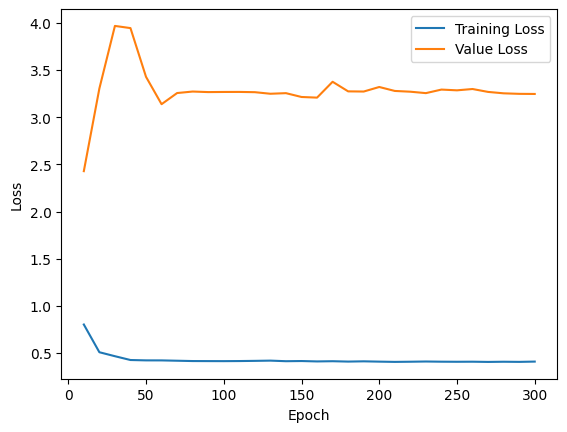

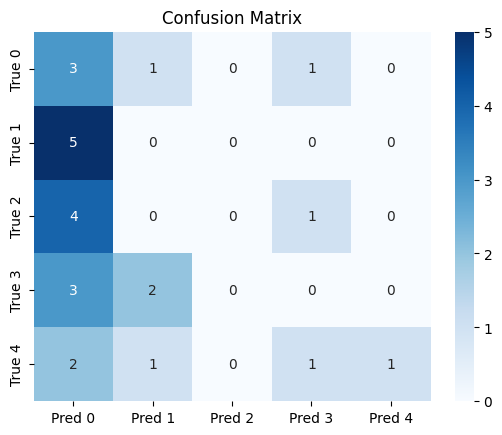

              precision    recall  f1-score   support

           0       0.18      0.60      0.27         5
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         5
           4       1.00      0.20      0.33         5

    accuracy                           0.16        25
   macro avg       0.24      0.16      0.12        25
weighted avg       0.24      0.16      0.12        25



C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\semee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [181]:
n_gest = 5
model = GestNet(n_channels=22, time_steps=1000, n_gest=5)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

train_losses = []
val_losses   = []
x_ax         = []

assert x.shape[0] == y.shape[0],           "x and y batch size mismatch"
assert x_test.shape[0] == y_test.shape[0], "x_test and y_test batch size mismatch"
assert x.shape[1] == 22,                   "Expected 22 EEG channels"
assert y.min() >= 0,                       "Labels must be >= 0"
assert y.max() < n_gest,                   f"Label {y.max()} out of bounds for n_gest={n_gest}"
assert y.dtype == torch.long,              "Labels must be torch.long"

print(f"Classes in train: {torch.unique(y).tolist()}")
print(f"Classes in test:  {torch.unique(y_test).tolist()}")
print(f"x mean/std: {x.mean():.3f} / {x.std():.3f}")  # should be ~0 / ~1 if normalised

epoch = 300
for i in range(epoch):
    model.train()
    optimizer.zero_grad()
    x_aug = augment_eeg(x)
    logits = model(x_aug)          # (batch, n_gest)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if (i + 1) % 10 == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():  
            logits_test = model(x_test)
            val_loss = criterion(logits_test, y_test)
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        x_ax.append(i+1)

model.eval()
with torch.no_grad():
    val_logits = model(x_test)
    val_preds  = torch.argmax(val_logits, dim=-1)

print("Predicted class distribution:")
for c in range(n_gest):
    count = (val_preds == c).sum().item()
    print(f"  Class {c}: {count} predictions")

print("\nActual class distribution:")
for c in range(n_gest):
    count = (y_test == c).sum().item()
    print(f"  Class {c}: {count} samples")


plt.plot(x_ax, train_losses)
plt.plot(x_ax, val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
labels = ["Training Loss", "Value Loss"]
plt.legend(labels)
plt.show()

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test.cpu(), val_preds.cpu())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {i}' for i in range(n_gest)],
            yticklabels=[f'True {i}' for i in range(n_gest)])
plt.title("Confusion Matrix")
plt.show()

# Per-class precision, recall, F1
print(classification_report(y_test.cpu(), val_preds.cpu()))